# Quality control of sc/snRNA-seq

To perform quality control of single-cell or single-nuclei RNA sequencing (sc/snRNA-seq) we have the `dotools_py.pp.importer_py()` function. This function compiles different methods to process samples. We need to define a list of H5 files that have been generated from a mapping tool like [CellRanger](https://www.10xgenomics.com/support/software/cell-ranger/latest) or [STARsolo](https://github.com/cellgeni/STARsolo). If [CellBender](https://github.com/broadinstitute/CellBender) has been run, we can also provide the path to the H5 files generated by CellBender. Additionally, we need to provide the batch names for the samples, and additional metadata can be provided in the form of a dictionary.

The quality control involves filtering genes and cells:
- **Genes**: are removed based on their expression levels. Genes expressed in low amount of cells are excluded. By default, we consider that a gene is excluded if it is expressed in less than 5 cells
- **Cells**: are removed based on different parameters, including: number of genes, mitochondrial content, doublets and number of UMI counts.
    - Mitochondrial content: cells with high mitochondrial content are excluded. We recomment assuming a maximum un 5 % for scRNA-seq and 3% for snRNA-seq
    - Doublets: we implemented three different approaches for the identification of neotypic doublets (i.e, doublets originating from the combination of two or more different cell-types). The available implementations are [scDblFinder](https://github.com/plger/scDblFinder), [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [Scrublet](https://github.com/swolock/scrublet).
    - Number of genes: cells are removed by absolute number of genes. A lower and upper threshold can be set.
    - Number of UMI counts: cells can be removed using two approaches: absolute or quantiles. A lower and upper threshold can be set and a combination of both approaches can be used (e.g., an absolute lower threshold and filter cells on the upper quantile).

After the quality control per sample, the individual samples will be combined into one AnnData object and log-normalisation, scaling and highly variable genes  will be calculated. To evaluate the quality control the distribution of total UMI, number of genes and mitochondrial genes per cell will be plotted in a violin plot before and after the quality control. These plots will be saved in the folders containing the H5 files. Additionally, we also keep track on the number of cells and genes that have been removed in each quality control step.

First, we start setting up the environment and loading the required libraries

## Environment setup

In [1]:
import dotools_py as do
import pandas as pd
from IPython.display import display, SVG
import session_info

2026-03-05 17:09:39,729 - Jupyter enviroment detected. Using "inline" backend


To show how the quality control works, we are going to use a public dataset from 10X from human blood of healthy and donors with a malignant tumor. We get the raw and the filtered H5 files generated by 10X.


In [2]:
do.dt.example_10x("/Users/david/Downloads/PublicData10x")

2025-10-22 16:16:29,452 - Downloading data to /Users/david/Downloads/PublicData10x


## Sequential preprocessing

In [2]:
paths = [
    "/Users/david/Downloads/PublicData10x/healthy/outs/filtered_feature_bc_matrix.h5",
    "/Users/david/Downloads/PublicData10x/disease/outs/filtered_feature_bc_matrix.h5",
]

adata = do.pp.importer_py(
    paths=paths,
    ids=["batch1", "batch2"],
    metadata={"condition": ["healthy", "disease"]},  # Additional metadata information
    batch_key="batch",  # Column in obs to save batch information
    remove_doublets=True,
    doublet_tool="scDblFinder",  # Tool to identify neotypic doublets (Also available Scrublet and DoubletDetection)
    min_genes_in_cell=300,
    min_cells_with_genes=5,
    cut_mt=5,
    n_reads=10_000,
    min_counts=500,  # Filter cells with less than 500 genes
    high_quantile=95,  # Filter cells with the top 5% high number of UMI counts
)

2026-03-05 17:09:43,146 - For snRNA a lower 'cut_mt' is recommended since mitochondrial genes
 should not be highly expressed in the nuclei
2026-03-05 17:09:43,147 - QualityControl Plots will be saved in
/Users/david/Downloads/PublicData10x/healthy/outs
reading /Users/david/Downloads/PublicData10x/healthy/outs/filtered_feature_bc_matrix.h5
 (0:00:00)
2026-03-05 17:09:43,929 - Remove cells with low number of genes
filtered out 14 cells that have less than 300 genes expressed
2026-03-05 17:09:44,012 - Remove genes lowly expressed
filtered out 16694 genes that are detected in less than 5 cells
2026-03-05 17:09:44,121 - Remove cells with high Mt-content
2026-03-05 17:09:44,138 - Remove cells based on nUMI counts


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In check.deprecation(deprecated_cv_params, match.call(), ...) :  
R callback write-console: 
   
R callback write-console:  Passed invalid function arguments: max_depth, eval_metric, tree_method, subsample, nthread, eta. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version.
  
R callback write-console: 2:   
R callback write-console: In throw_err_or_depr_msg("Parameter(s) have been removed from this function: ",  :  
R callback write-console: 
   
R callback write-console:  Parameter(s) have been removed from this function: label. This warning will become an error in a future version.
  
R callback write-console: 3:   
R callback write-console: In check.deprecation(deprecated_cv_params, match.call(), ...) :  
R 

2026-03-05 17:09:57,862 - Removed 94 doublets
2026-03-05 17:09:58,182 - QualityControl Plots will be saved in
/Users/david/Downloads/PublicData10x/disease/outs
reading /Users/david/Downloads/PublicData10x/disease/outs/filtered_feature_bc_matrix.h5
 (0:00:00)
2026-03-05 17:09:58,671 - Remove cells with low number of genes
filtered out 46 cells that have less than 300 genes expressed
2026-03-05 17:09:58,753 - Remove genes lowly expressed
filtered out 16250 genes that are detected in less than 5 cells
2026-03-05 17:09:58,845 - Remove cells with high Mt-content
2026-03-05 17:09:58,850 - Remove cells based on nUMI counts


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In check.deprecation(deprecated_cv_params, match.call(), ...) :  
R callback write-console: 
   
R callback write-console:  Passed invalid function arguments: max_depth, eval_metric, tree_method, subsample, nthread, eta. These should be passed as a list to argument 'params'. Conversion from argument to 'params' entry will be done automatically, but this behavior will become an error in a future version.
  
R callback write-console: 2:   
R callback write-console: In throw_err_or_depr_msg("Parameter(s) have been removed from this function: ",  :  
R callback write-console: 
   
R callback write-console:  Parameter(s) have been removed from this function: label. This warning will become an error in a future version.
  
R callback write-console: 3:   
R callback write-console: In check.deprecation(deprecated_cv_params, match.call(), ...) :  
R 

2026-03-05 17:10:01,013 - Removed 27 doublets
2026-03-05 17:10:01,200 - Concatenating samples
2026-03-05 17:10:01,280 - Normalisation of the expression
normalizing counts per cell
    finished (0:00:00)
2026-03-05 17:10:01,302 - Finding Highly Variable Genes shared across samples
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
2026-03-05 17:10:01,575 - Run PCA
computing PCA
    with n_comps=50
    finished (0:00:00)


In [3]:
adata

AnnData object with n_obs × n_vars = 2774 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg'
    obsm: 'X_pca'
    layers: 'counts', 'logcounts'

## Evaluation of the preprocessing

We can now check the quality control plots that were generated:


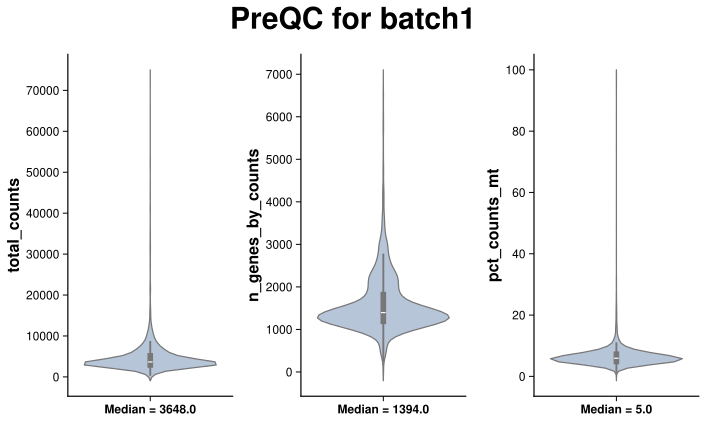

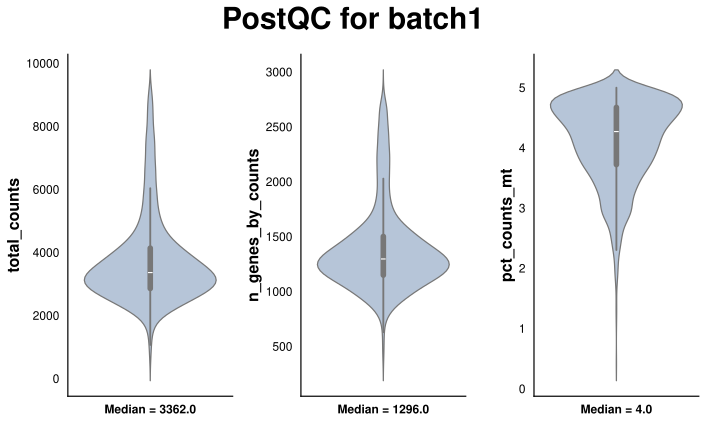

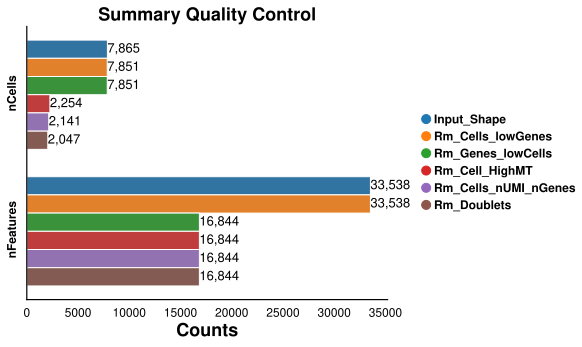

In [5]:
files = [
    "/Users/david/Downloads/PublicData10x/healthy/outs/Vln_PreQC_batch1.svg",
    "//Users/david/Downloads/PublicData10x/healthy/outs/Vln_PostQC_batch1.svg",
    "/Users/david/Downloads/PublicData10x/healthy/outs/260305_QC_Metricsbatch1.svg"
]

display(
    SVG(files[0]),
    SVG(files[1]),
    SVG(files[2]),
)

We can observe that the majority of cells were remove due to high mitochondrial content. Depending on the experimental set-up we might want to increase the threshold of mitochondrial content if we do not want to lose too many cells. Besides these plots, we also have an ExcelSheet that kept track on the thresholds used during the quality control.

In [6]:
table = pd.read_excel("/Users/david/Downloads/PublicData10x/healthy/outs/260305_Metrics_batch1.xlsx")
table

,QC_Step,nCells,nFeatures,Comments
0,Input_Shape,7865,33538,NaN
1,Rm_Cells_lowGenes,7851,33538,Remove cells with <300 genes
2,Rm_Genes_lowCells,7851,16844,Remove genes express in less than 5 cells
3,Rm_Cell_HighMT,2254,16844,Remove cells with >5% of Mitochondrial genes
4,Rm_Cells_nUMI_nGenes,2141,16844,Remove cells based on nUMI counts[Absolute (Mi...
5,Rm_Doublets,2047,16844,Remove neotypic doublets using scDblFinder


## Integration and clustering
After the quality control, we can now proceed to the batch correction and integration of the samples. For these, we can use different batch correction methods: [Harmony](https://www.nature.com/articles/s41592-019-0619-0), [Scanorama](https://www.nature.com/articles/s41596-024-00991-3), [BBKNN](https://academic.oup.com/bioinformatics/article/36/3/964/5545955?login=true), [scVI](https://www.nature.com/articles/s41587-021-01206-w) or [CCA](https://www.sciencedirect.com/science/article/pii/S0092867419305598?via%3Dihub) from Seurat (v4 or v5 approach). After the integration of the samples, we run the [Leiden](https://www.nature.com/articles/s41598-019-41695-z) algorithm to find clusters and generate the UMAP embeddings for visualisation.

In [7]:
do.tl.integrate_data(
    adata,
    batch_key="batch",
    hvg_batch=True,
    integration_method="cca5",
    resolution=0.3,  # Resolution for leiden algorithm
)

2026-03-05 17:10:37,951 - Computing HVGs
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
2026-03-05 17:10:38,652 - Integration using CCA (Seurat v5 approach)
2026-03-05 17:10:38,654 - Preprocessing to export to Seurat
2026-03-05 17:10:38,687 - Running CCA Integration


Reading AnnData in R
Warning message:
Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
Starting ACC in R environment...
Run CCA with v5
Centering and scaling data matrix
  |======================================================================| 100%
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 2737 anchors
Merging dataset 2 into 1
Extracting anchors for merged samples
Finding integration vectors
Finding integration vector weights
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Integrating data


                          integratedcca_1 integratedcca_2 integratedcca_3
AAACCCAGTGCATTTG-1-batch1      -29.317470       0.3862413       -4.324833
AAACCCATCTCAACGA-1-batch1        4.571685      -1.2351645       -4.032547
AAACCCATCTCTCGAC-1-batch1        4.236896      -1.4202744       -3.751133
2026-03-05 17:11:00,514 - Loading corrected matrix


Warning messages:
1: Input is a v3 assay and `split()` only works for v5 assays; converting
• to a v5 assay 
2: package ‘future’ was built under R version 4.5.2 
Preparing to export to python...
Saving data in 
/tmp/CCA_9972592b974942f18ed9d3cb67556291/adata_hvg_seurat_AnchorIntegration.csv


2026-03-05 17:11:00,689 - Finding neighbors
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
2026-03-05 17:11:02,938 - Run UMAP
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:02)
2026-03-05 17:11:05,779 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


 We can observe, that after the integration we have `X_CCA` in `obsm`. This is the CCA matrix after dimensionality reduction. Contrary to the approach in Seurat4 where  the dimensions of this matrix is  n_cells x n_hvg, in this case the dimension is n_cells x 50

In [8]:
adata.obsm["X_CCA"].shape

(2774, 50)

## Evaluation of integration
We can now visualise the integrated object and the identified clusters:

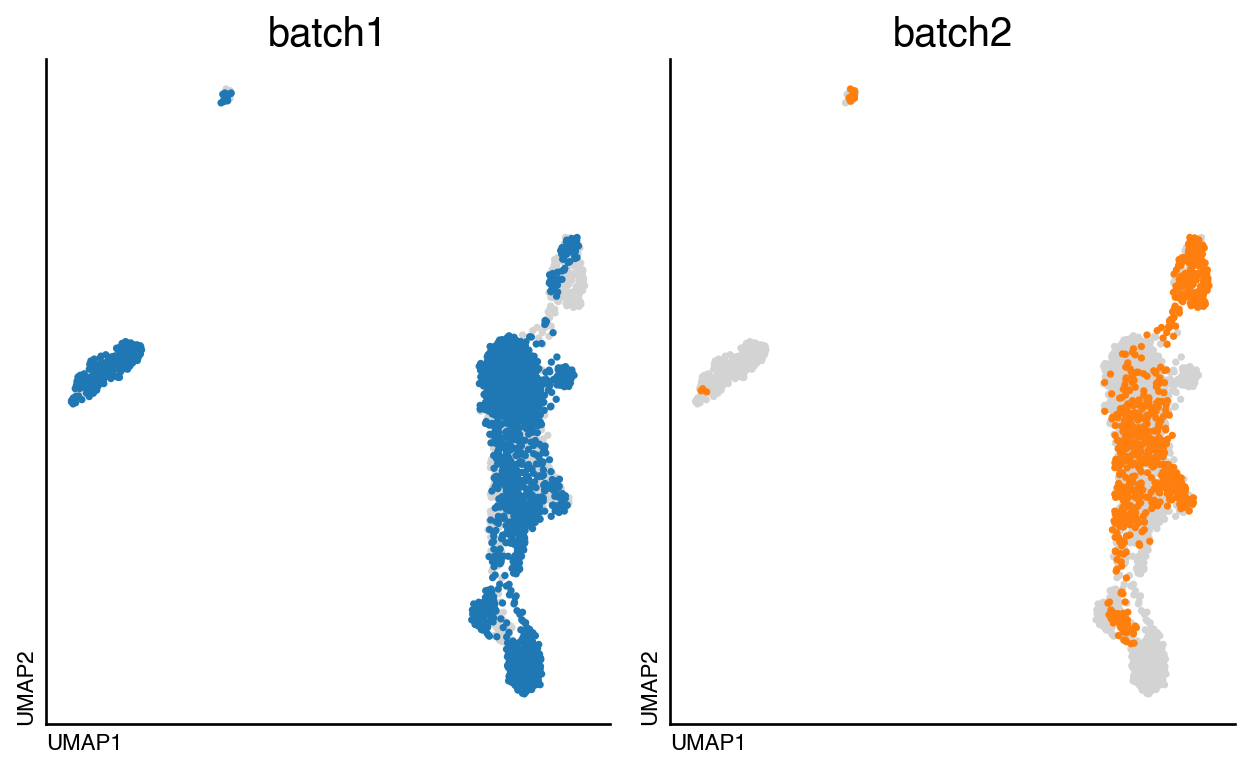

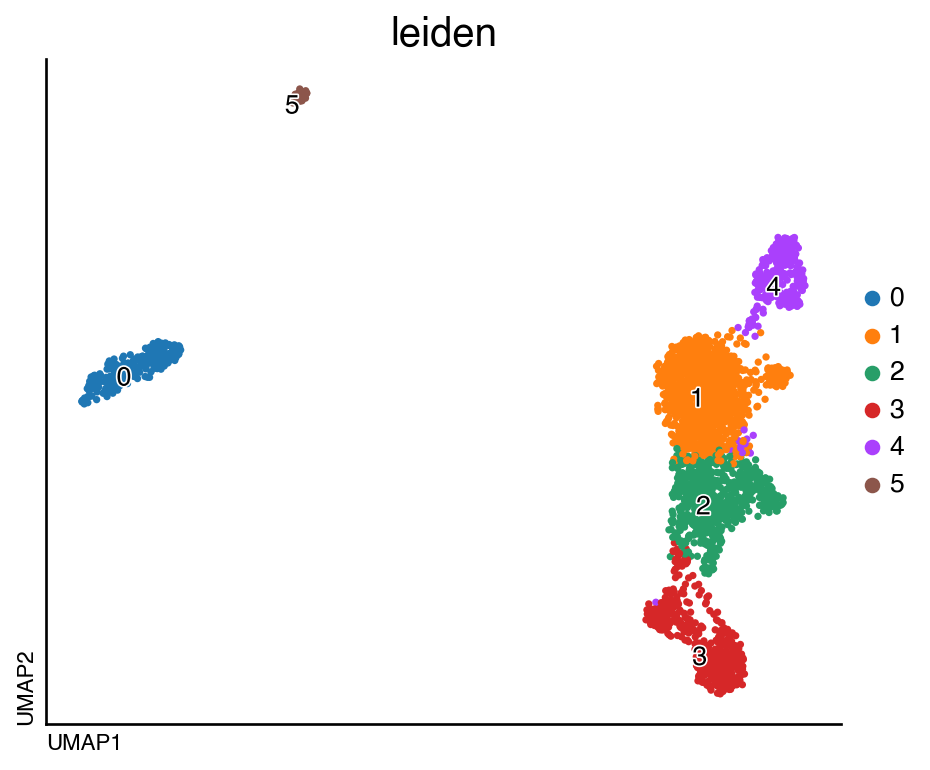

<Figure size 320x400 with 0 Axes>

In [9]:
do.pl.split_embedding(adata, "batch", figsize=(8, 5))
do.pl.umap(adata, "leiden", labels="leiden", figsize=(6, 5))

In [10]:
adata.write("/Users/david/Downloads/PublicData10x/adata.h5ad")

## Semi-automatic annotation with CellTypist

We also have the possibility to perform a semi-automatic annotation using [CellTypist](https://www.celltypist.org/). In this case, we use the  `Adult_COVID19_PBMC.pkl` model.

🔬 Input data has 2774 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 3323 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


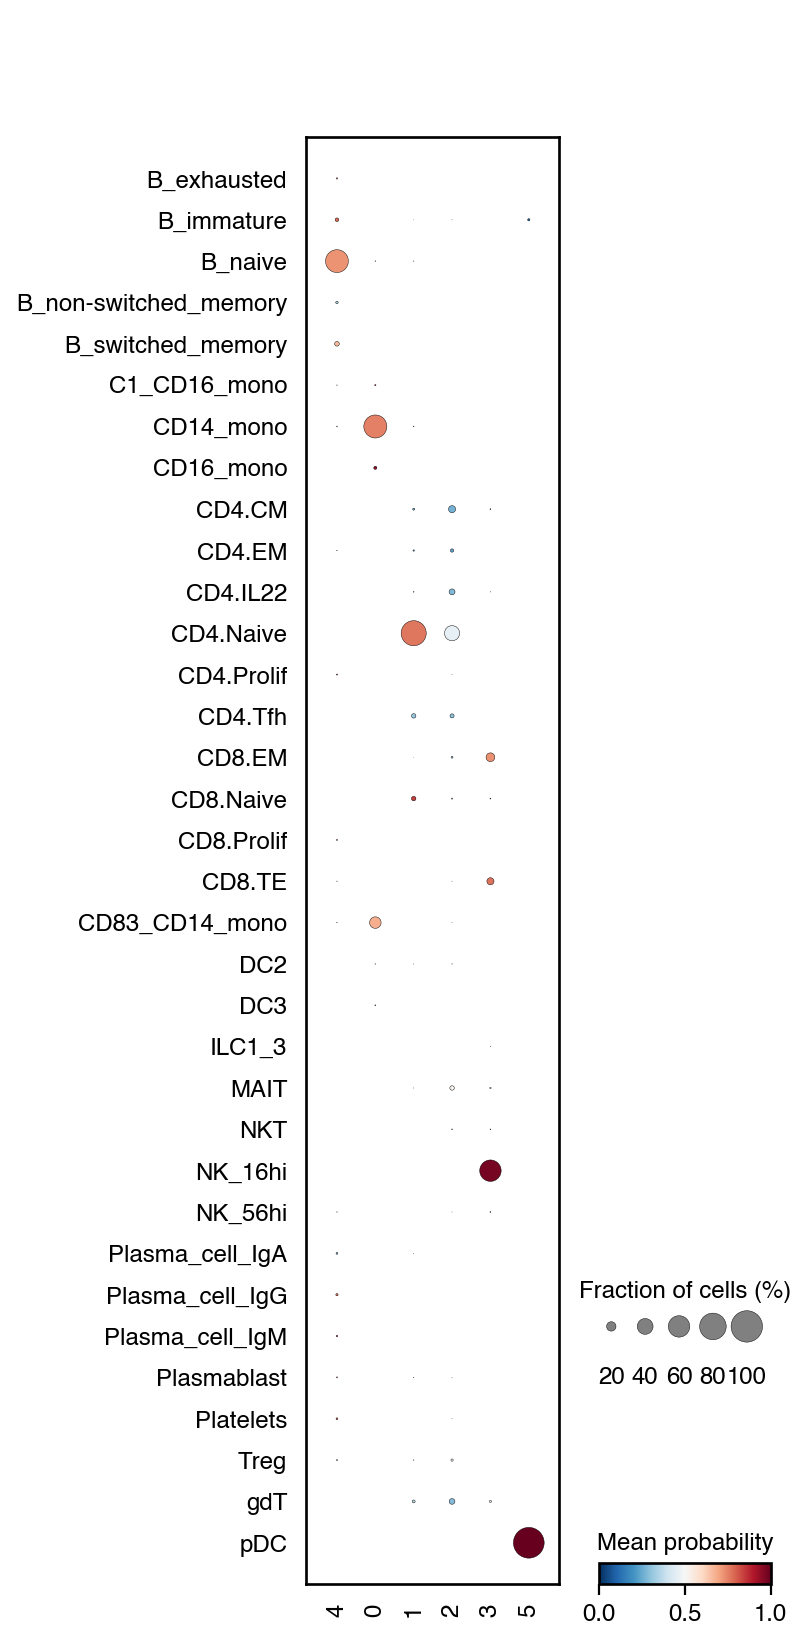

In [11]:
do.tl.auto_annot(adata, "leiden", model="Healthy_COVID19_PBMC.pkl", convert=False, pl_cell_prob=True)

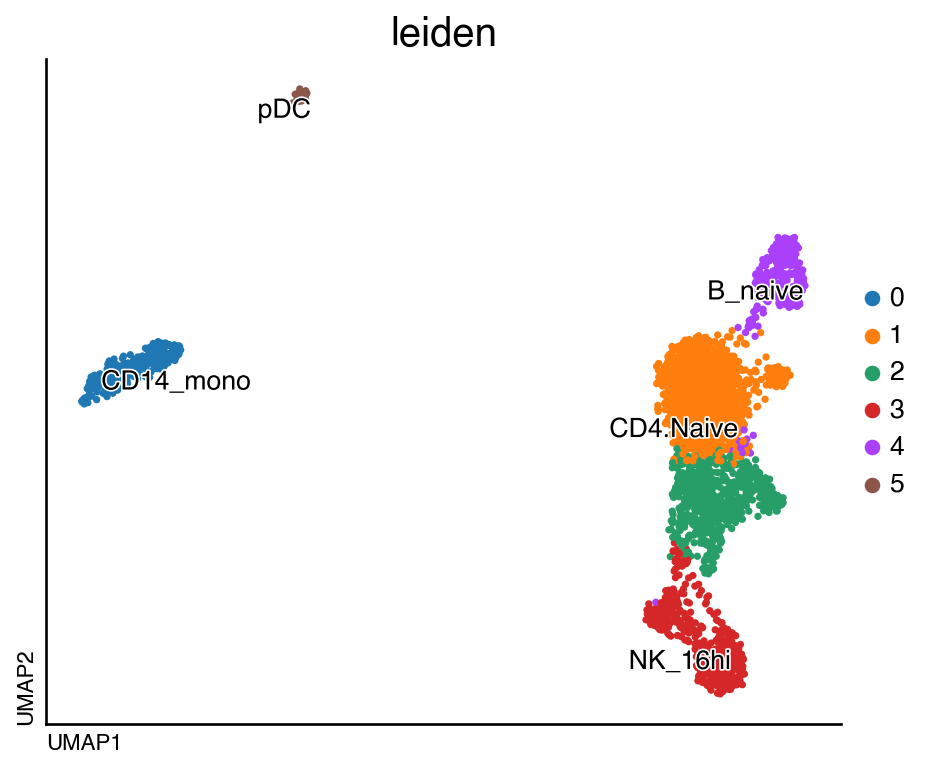

<Figure size 320x400 with 0 Axes>

In [12]:
do.pl.umap(adata, "leiden", labels="autoAnnot")

Besides the semi-automatic annotation, we should also validate the findings with  known markers for these celltypes.


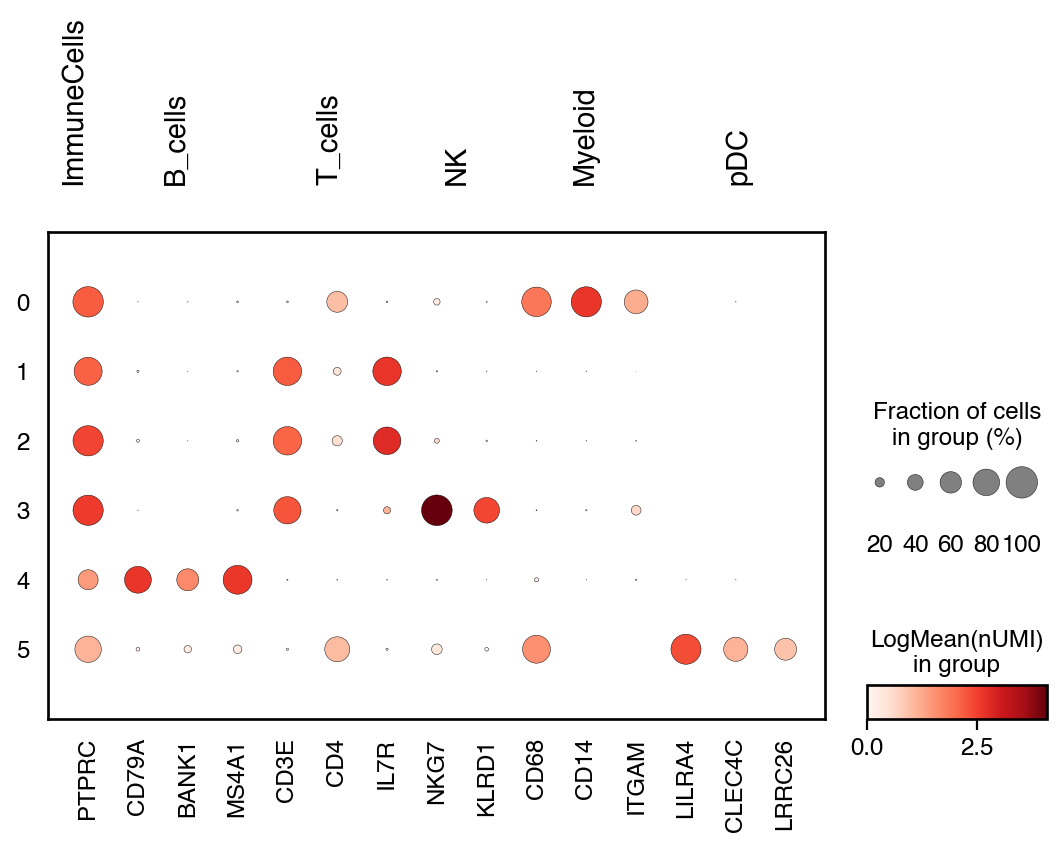

In [13]:
markers = {
    "ImmuneCells": ["PTPRC"],
    "B_cells": ["CD79A", "BANK1", "MS4A1"],
    "T_cells": ["CD3E", "CD4", "IL7R"],
    "NK": ["NKG7", "KLRD1"],
    "Myeloid": ["CD68", "CD14", "ITGAM"],
    "pDC": ["LILRA4", "CLEC4C", "LRRC26"],
}

do.pl.dotplot(adata, "leiden", markers, swap_axes=False, var_group_rotation=90)

Overall we can see an agreement with the annotation and can continue with the annotation.

... storing 'annotation' as categorical


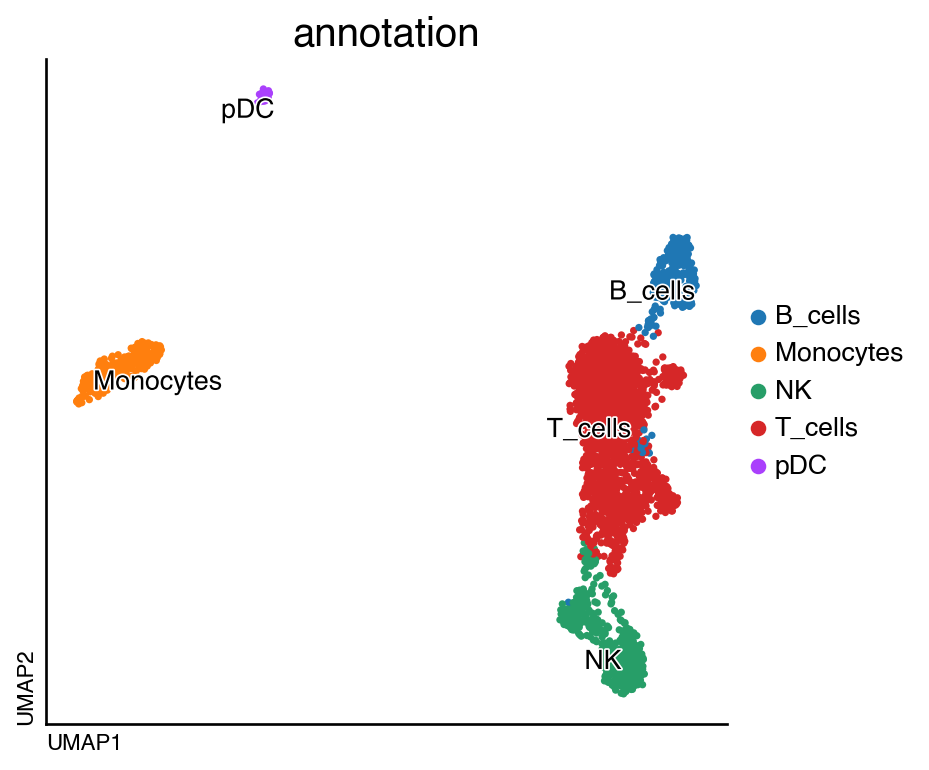

<Figure size 320x400 with 0 Axes>

In [14]:
adata.obs["annotation"] = adata.obs.leiden.map(
    {"0": "Monocytes", "1": "T_cells", "2": "T_cells", "3": "NK", "4": "B_cells", "5": "pDC"}
)
do.pl.umap(adata, "annotation", labels="annotation")

## Evaluate changes in cell population
After the annotation of the cell-type populations, we can also evaluate if there are significant changes in these populations in the healthy and diseased condition using [scanpro](https://github.com/loosolab/scanpro).

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 0.86 seconds
2026-03-05 17:11:35,142 - There are 3 populations with a significant change


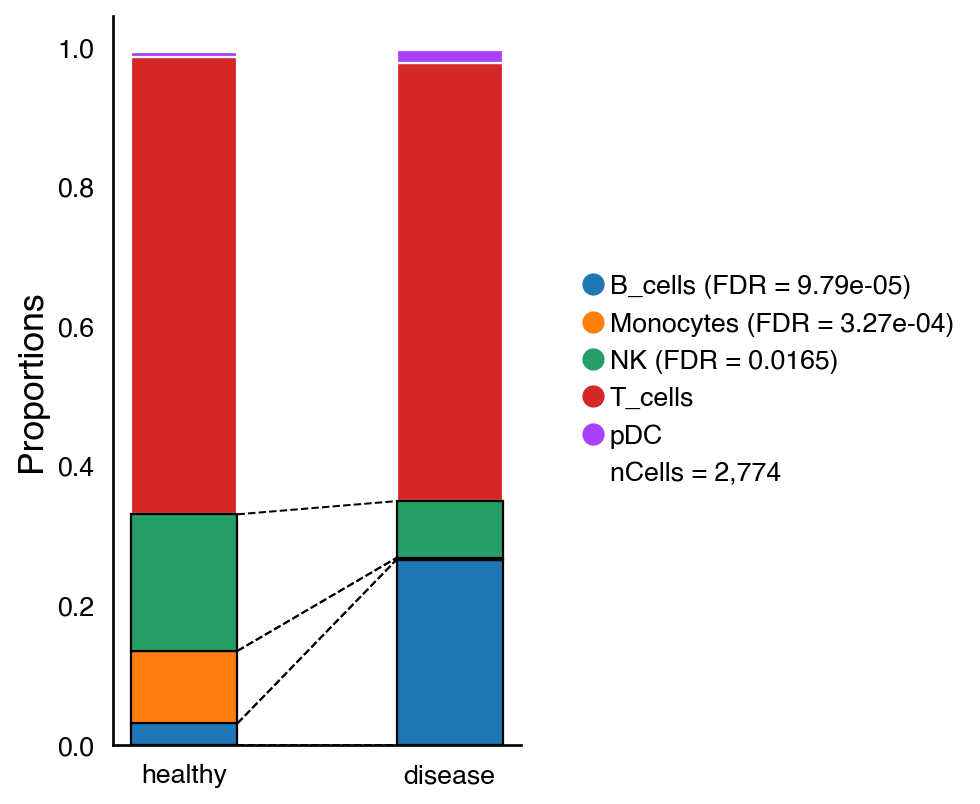

In [15]:
do.pl.cell_composition(
    adata,
    annot_key="annotation",
    condition_key="condition",
    batch_key="batch",
    transform="arcsin",  # Produce more accurate results for simulated data
    condition_order=["healthy", "disease"],
)

Cell populations with a significant change are connected by discontinued lines and the p-value is indicated in the legend. In this case, we see a significant change in B cells, Monocytes and NK cells.

## Reclustering of a cell population

If we are interested in specific states for a cell-type, we can also perform re-clustering. In this case, we are going to focus on the biggest cluster, the T cells.

2026-03-05 17:11:50,299 - Reclustering using CCA5 approach
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:01)
running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


... storing 'annotation_recluster' as categorical


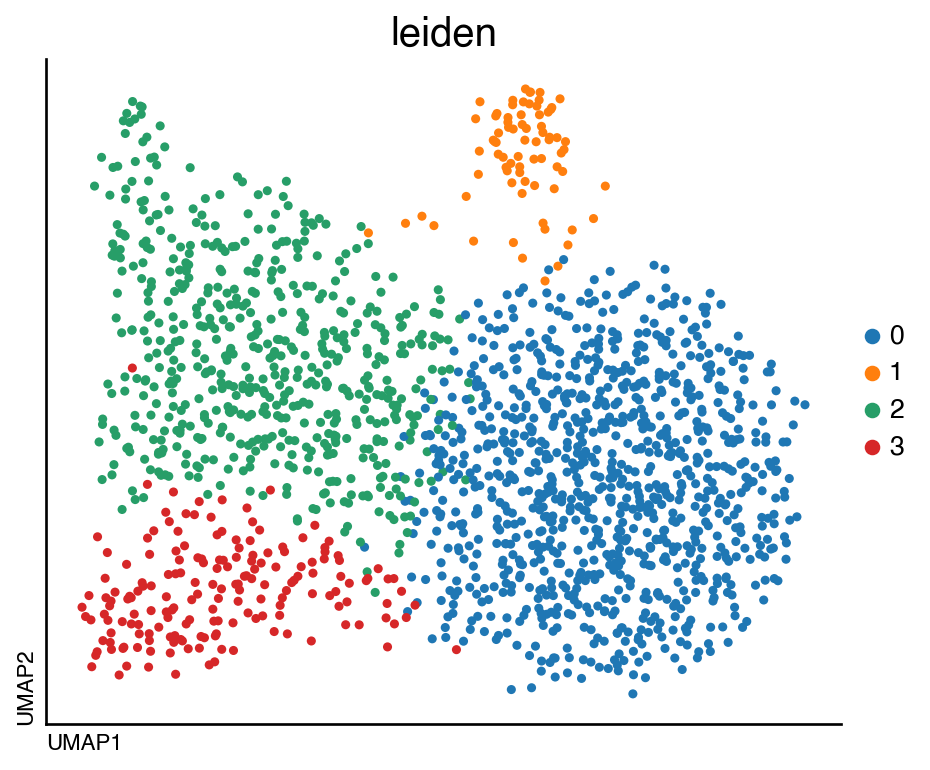

<Figure size 320x400 with 0 Axes>

In [16]:
tcell = do.tl.reclustering(
    adata,
    cluster_key="annotation",  # Metadata column with clusters
    batch_key="batch",  # Metadata column with batch information
    recluster_approach="cca5",  # Integration approach used
    use_clusters=["T_cells"],  # Cluster we want to re-cluster
    use_rep="X_CCA",  # representation to use
    get_subset=True,  # Get AnnData of T_cells re-clusters
    resolution=0.6,
)
do.pl.umap(tcell, "leiden")

We identified 5 clusters, to evaluate if there are subtypes of T_cells we can identify the top markers for each cluster.

In [17]:
do.tl.rank_genes_groups(tcell, groupby="leiden", method="wilcoxon", tie_correct=True, pts=True)
table = do.get.dge_results(tcell)
table_filt = table[(table.log2fc > 0.25) & (table.padj < 0.05)]

for group in table_filt.group.unique():
    display(table_filt[table_filt.group == group].head(6))

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:05)


,group,GeneName,statistic,log2fc,pvals,padj,pts_group,pts_ref
0,0,RPS3A,24.220013,0.578721,1.369331e-129,8.451970e-126,0.998967,1.000000
1,0,RPS13,23.757196,0.637562,9.258045e-125,4.285781e-121,0.998967,0.998788
2,0,RPL30,22.125813,0.443310,1.783986e-108,6.606813e-105,1.000000,1.000000
3,0,RPS23,21.858437,0.484084,6.461934e-106,1.994260e-102,1.000000,0.998788
4,0,RPL32,21.758680,0.449734,5.717034e-105,1.512319e-101,1.000000,1.000000
5,0,RPS27A,21.066700,0.436605,1.607524e-98,3.720816e-95,1.000000,0.998788


,group,GeneName,statistic,log2fc,pvals,padj,pts_group,pts_ref
18517,1,LINC02446,35.053997,7.035328,3.388997e-269,6.275405e-265,0.813333,0.005821
18518,1,CD8B,32.606480,6.153499,3.319344e-233,3.073215e-229,0.906667,0.020373
18519,1,CD8A,29.618280,5.450690,8.691222e-193,5.364512e-189,0.760000,0.016298
18520,1,CD8B2,14.531270,6.848237,7.678328e-48,3.554490e-44,0.146667,0.001164
18521,1,CTSW,13.804950,2.810720,2.379395e-43,8.811850e-40,0.666667,0.119907
18522,1,S100B,10.849152,5.708410,2.012853e-27,6.193968e-24,0.120000,0.003492


,group,GeneName,statistic,log2fc,pvals,padj,pts_group,pts_ref
37034,2,ANXA1,21.476015,2.394850,2.609595e-102,4.832187e-98,0.748252,0.250614
37035,2,S100A4,20.369370,1.968216,3.126732e-92,2.894885e-88,0.865385,0.505324
37036,2,B2M,19.312704,0.441488,4.199950e-83,2.592349e-79,1.000000,1.000000
37037,2,S100A11,19.250797,1.834325,1.390048e-82,6.434877e-79,0.723776,0.284193
37038,2,ITGB1,18.959566,2.128073,3.681748e-80,1.363499e-76,0.596154,0.158067
37039,2,ANXA2,17.910473,2.517298,9.770188e-72,2.261432e-68,0.423077,0.066339


,group,GeneName,statistic,log2fc,pvals,padj,pts_group,pts_ref
55551,3,IKZF2,20.558655,3.792305,6.439410e-94,1.192386e-89,0.477528,0.037152
55552,3,RTKN2,18.475254,3.668481,3.266805e-76,3.024572e-72,0.455056,0.047059
55553,3,TIGIT,17.810202,3.052925,5.889649e-71,3.635287e-67,0.533708,0.076780
55554,3,CTLA4,17.165768,2.865431,4.791085e-66,2.217913e-62,0.528090,0.081734
55555,3,FOXP3,16.695776,4.500996,1.406768e-62,5.209826e-59,0.280899,0.016099
55556,3,TNFRSF9,15.840305,6.292408,1.640226e-56,4.338867e-53,0.191011,0.004334


From the list of markers, cluster 3 seems to express markers for T regulatory cells. while cluster 1 seems to be enriched in cytotoxic markers. We can visualise the distribution of these genes.

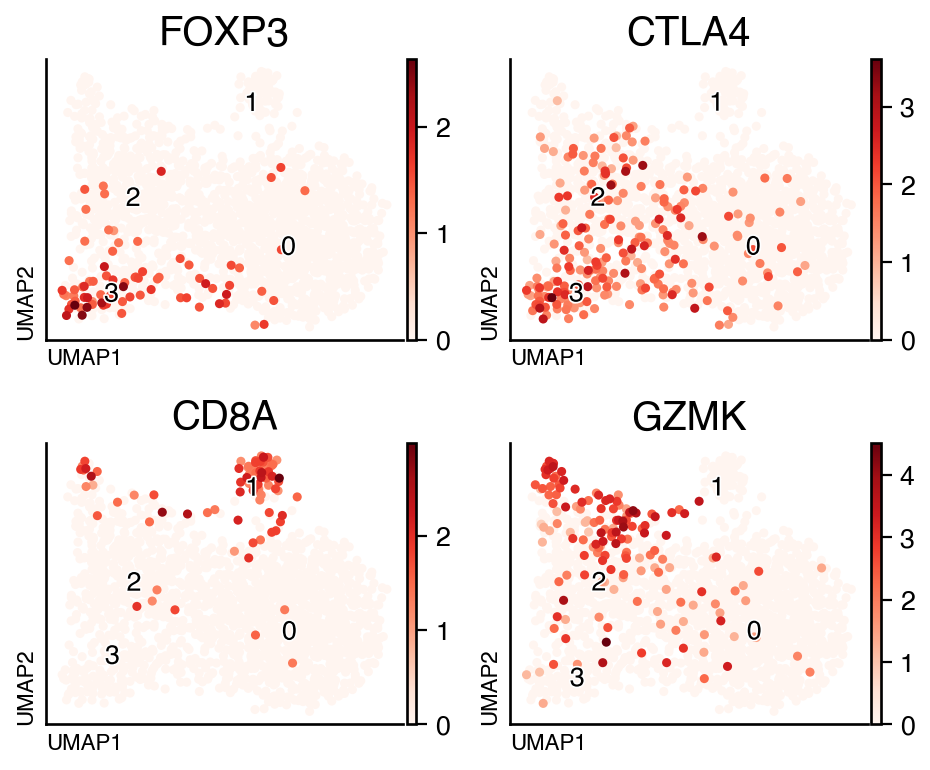

<Figure size 320x400 with 0 Axes>

In [18]:
do.pl.umap(tcell, ["FOXP3", "CTLA4", "CD8A", "GZMK"], ncols=2, labels="leiden")

From this list of markers, we can see that cluster 1 is enriched for cytotoxic markers. We can transfer this annotation to our original object and evaluate again changes in the cell population.

... storing 'annotation_recluster' as categorical


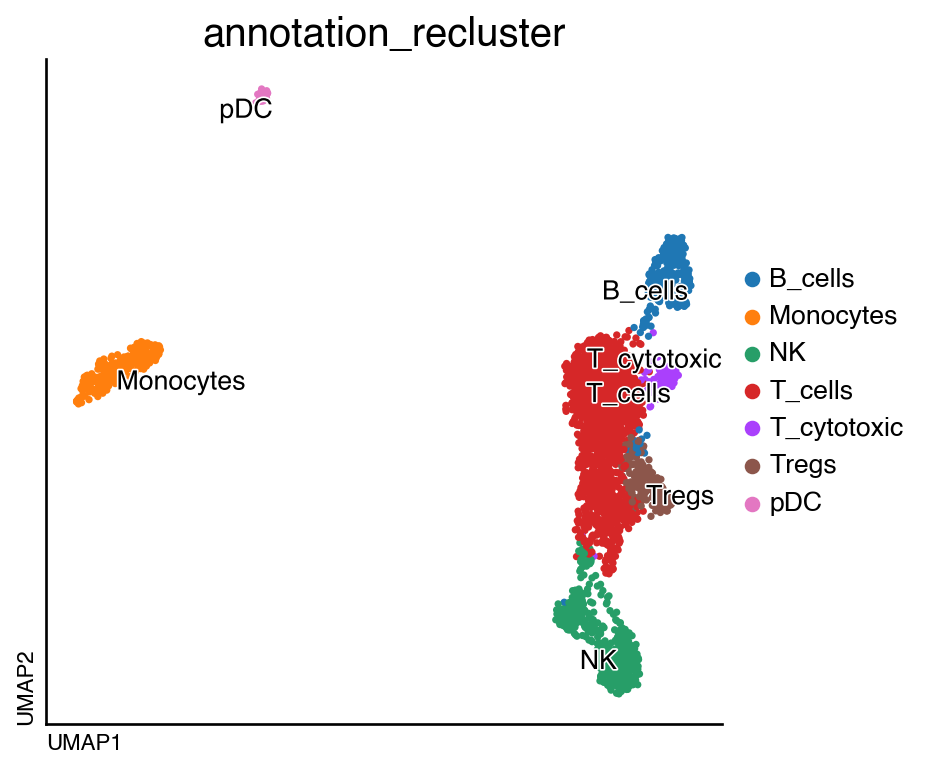

<Figure size 320x400 with 0 Axes>

In [19]:
tcell.obs["annotation_recluster"] = tcell.obs.leiden.map(
    {"0": "T_cells", "1": "T_cytotoxic", "2": "T_cells", "3": "Tregs", "4": "T_cells"}
)
adata.obs["annotation_recluster"] = adata.obs["annotation"].copy()
do.utility.transfer_labels(
    adata_original=adata,
    adata_subset=tcell,
    original_key="annotation_recluster",
    subset_key="annotation_recluster",
    original_labels=["T_cells"],
)
do.pl.umap(adata, "annotation_recluster", labels="annotation_recluster")

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 1.07 seconds
2026-03-05 17:12:11,441 - There are 5 populations with a significant change


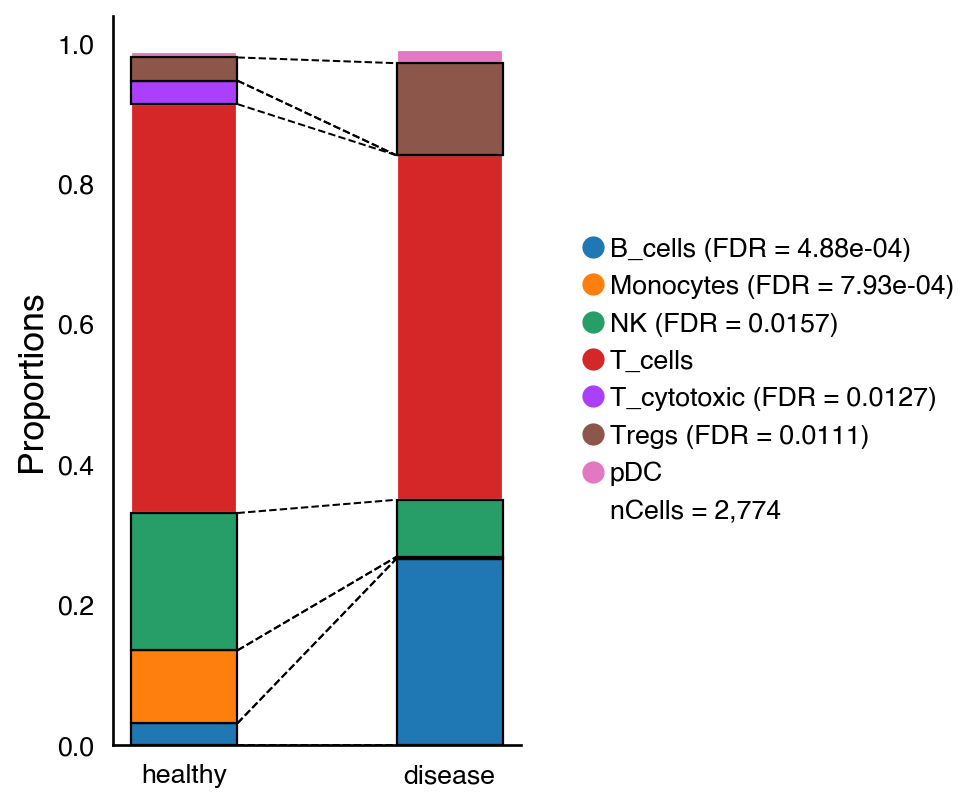

In [20]:
do.pl.cell_composition(
    adata,
    annot_key="annotation_recluster",
    condition_key="condition",
    batch_key="batch",
    transform="arcsin",
    condition_order=["healthy", "disease"],
)

We can see that even though there is a decrease in the proportion of T_cytotoxic, the change is not significant. On the other hand, the regulatory T cells increase significantly.

## Gene Ontology analysis

We can also evaluate which biological processes are enriched in a cell-type in each condition by performing gene ontology analysis. First, we need to identified differentially expressed genes. We are going to focus on T cells. We can use `do.tl.go_analysis()` to run gene set analysis using the enrichR API. This function, will split differentially express genes in up- and down-regulated and run the analysis for each set.

In [21]:
tcell = adata[adata.obs.annotation == "T_cells"]
do.tl.rank_genes_groups(
    tcell, groupby="condition", method="wilcoxon", tie_correct=True, pts=True, reference="healthy", groups=["disease"]
)
table = do.get.dge_results(tcell)
df = do.tl.go_analysis(
    table,
    gene_key="GeneName",
    pval_key="padj",
    log2fc_key="log2fc",
    log2fc_cutoff=0.25,  # It will take -0.25 and +0.25
    specie="Human",
    go_catgs=["GO_Biological_Process_2023"],
)
df.head(10)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
2026-03-05 17:12:40,599 - Running GSA on Up- and Down-regulated genes


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,state
0,GO_Biological_Process_2023,Regulation Of Apoptotic Process (GO:0042981),116/705,1.028501e-11,4.284737e-08,0,0,2.147309,54.327632,TFRC;ARL6IP1;CIB1;FAIM2;TNF;IKZF3;CCND2;EPC1;P...,enriched
1,GO_Biological_Process_2023,Positive Regulation Of Cytokine Production (GO...,66/320,2.493362e-11,5.193672e-08,0,0,2.800421,68.371737,IL21;ITK;HILPDA;RORA;PTPN22;TNF;IFIH1;PNP;PDE4...,enriched
2,GO_Biological_Process_2023,Regulation Of Gene Expression (GO:0010468),161/1127,1.145223e-10,1.590333e-07,0,0,1.829209,41.871053,ZNF331;TFRC;NAB1;NAB2;JMJD1C;RORA;PRDM2;AHR;NR...,enriched
3,GO_Biological_Process_2023,Positive Regulation Of Apoptotic Process (GO:0...,57/270,2.220200e-10,2.312339e-07,0,0,2.875168,63.909956,TOP2A;PRR7;BTG1;CTSV;TNF;ADAMTSL4;CTSL;CASP3;P...,enriched
4,GO_Biological_Process_2023,Regulation Of Cytokine Production (GO:0001817),40/167,2.438576e-09,2.031822e-06,0,0,3.366014,66.754292,IL21;PTGER4;ITK;HILPDA;ZBTB1;TNF;HDAC9;IFIH1;I...,enriched
5,GO_Biological_Process_2023,Regulation Of DNA-templated Transcription (GO:...,239/1922,3.152261e-09,2.188720e-06,0,0,1.571761,30.767450,ZNF296;JMJD1C;IKZF2;IKZF3;BACH1;IKZF5;SPIB;GPB...,enriched
6,GO_Biological_Process_2023,Regulation Of B Cell Proliferation (GO:0030888),18/44,8.281962e-09,4.312832e-06,0,0,7.344744,136.679712,IL21;IL10;LYN;VAV3;CD74;MEF2C;TFRC;TNFRSF13B;F...,enriched
7,GO_Biological_Process_2023,Response To Unfolded Protein (GO:0006986),18/44,8.281962e-09,4.312832e-06,0,0,7.344744,136.679712,HSPA8;PTPN1;HSP90AA1;HSP90AB1;HSPA4;RHBDD1;HSP...,enriched
8,GO_Biological_Process_2023,Negative Regulation Of Apoptotic Process (GO:0...,80/482,1.196966e-08,5.540624e-06,0,0,2.145098,39.128503,ARF4;TFRC;ARL6IP1;CITED2;CIB1;FAIM2;MTRNR2L8;T...,enriched
9,GO_Biological_Process_2023,Negative Regulation Of DNA-templated Transcrip...,140/1025,3.648046e-08,1.474492e-05,0,0,1.721391,29.481392,NAB1;GMNN;NAB2;ZBTB21;UBE2D1;HNRNPU;PRDM2;ARID...,enriched


We can visualise the top terms enriched in each condition with `do.pl.split_bar_gsea()`. But we need to do a pre-filtering to only consider significant terms.

2026-03-05 17:13:00,146 - !!! Assuming GO Terms are preprocessed (Only Significant terms included)


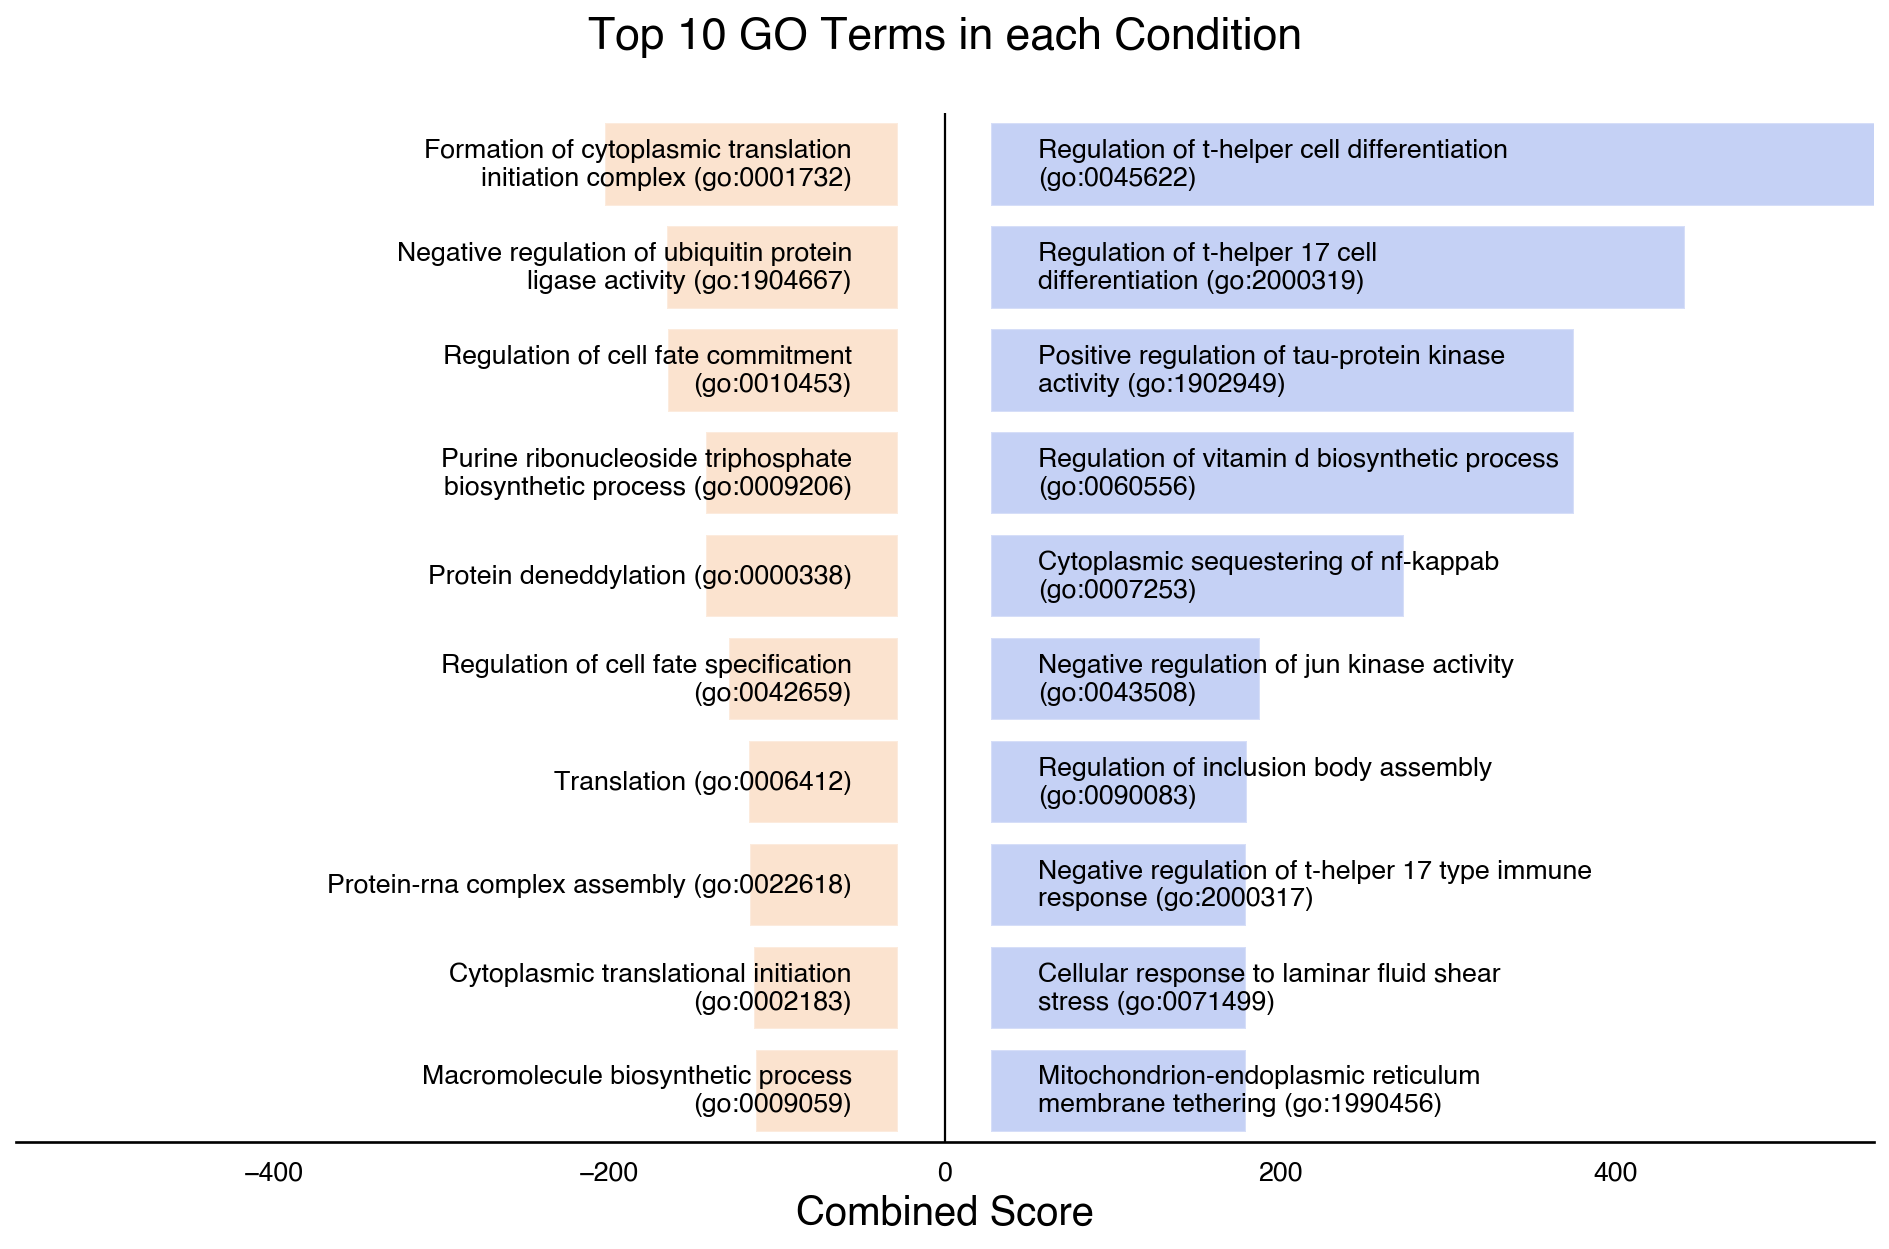

In [22]:
df_filt = df[df["Adjusted P-value"] < 0.05]
do.pl.split_bar_gsea(
    df_filt,
    term_col="Term",
    col_split="Combined Score",  # Column to use for the x-axis
    cond_col="state",  # Column that splits the up and down-regulated terms
    pos_cond="enriched",  # value in cond_col that should be in the positive axis
)

In [23]:
adata.write("/Users/david/Downloads/Data10x/adata.h5ad")

In [24]:
session_info.show(na=False, cpu=True, excludes=["backports"], std_lib=True, dependencies=True, html=True)